# ACTIVIDAD 05 PIPELINE

|                |   |
:----------------|---|
| **Nombre**     |  Claudio Alejo Encarnación Martínez |
| **Fecha**      |  17 septiembre 2026 |
| **Expediente** | 750597  |

## Explorar el dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
df = pd.read_excel('/Users/claudioalejoencarnacionmartinez/Documents/SEMESTRE OTOÑO 2026/LAB APRENDIZAJE ESTADÍSTICO/LABORATORIO-DE-APRENDIZAJE-ESTAD-STICO/Motor Trend Car Road Tests.xlsx')
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     str    
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 3.1 KB


## Planteamiento de hipótesis

Se analizará qué factores y en qué medida afectan el rendimiento de gasolina (mpg, millas por galón)

In [18]:
#Eliminar columna model
df = df.drop(columns=['model'])
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


### Caracterizar columnas y transformarlas

In [19]:
target_col = ['mpg']
num_cols = ['disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb'] #La escalaremos
cat_cols = ['cyl'] #OneHotEncoder
bool_cols = ['vs', 'am'] #Sin escalar


In [27]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


### Crear pipeline

In [28]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
        ('bool', 'passthrough', bool_cols)
    ], remainder='drop'
)

model = LinearRegression()

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])


### Regresión y visualización del pipeline

In [29]:
X = df.drop(columns=target_col)
y = df[target_col]
pipeline.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['cyl','disp','hp',...,'am','gear','carb']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the

### Acceder a coeficientes desde el pipeline

In [31]:
pipeline['model'].coef_

array([[ 1.6971302 , -3.112883  ,  0.01386703, -3.66559798,  1.13786856,
         0.69564657,  1.03562059,  0.55482605,  0.80974724,  0.00762231,
        -1.65268442,  1.64506211,  0.34509522,  0.50862673]])

### Calcular $R^2$

In [32]:
pipeline.score(X, y)

0.8816004757083714

#### Aquí podríamos meterle las Xnew, si tuviéramos nuevos datos, y como lo estamos haciendo por medio del pipeline, este los transformará en automático. En este caso no tenemos Xnew, así que solo usaremos X

In [33]:
pipeline.predict(X)

array([[21.80150128],
       [21.19320412],
       [26.27339254],
       [19.64456389],
       [17.7048002 ],
       [18.9797599 ],
       [14.23787722],
       [23.71748648],
       [24.1476536 ],
       [18.50749348],
       [18.89566774],
       [14.65788434],
       [16.08139993],
       [16.14987039],
       [12.62381558],
       [11.23162741],
       [10.30942516],
       [28.13041784],
       [30.87827206],
       [29.74197283],
       [23.22580617],
       [17.86186784],
       [18.27909328],
       [12.80657685],
       [16.73733055],
       [28.77448163],
       [25.52748501],
       [28.40797284],
       [18.06374086],
       [19.1778096 ],
       [14.6546904 ],
       [24.475059  ]])

### Gráfica de residuos

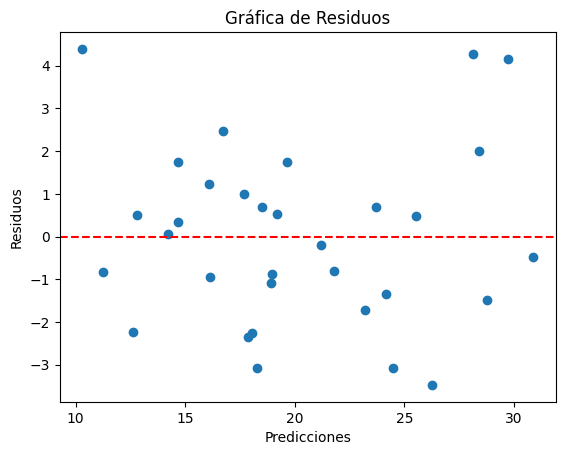

In [35]:
#Gráfica de residuos 
residuals = y - pipeline.predict(X)
plt.scatter(pipeline.predict(X), residuals)
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Gráfica de Residuos')
plt.axhline(y=0, color='r', linestyle='--')

### Cross validation con sklearn

In [ ]:
from sklearn.model_selection import cross_val_score

In [41]:
# Hacer cross-validation con cross_val_score
scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2')

print("Puntuaciones R²:", scores)
print("R² promedio:", scores.mean())
print("Desviación estándar:", scores.std())

Puntuaciones R²: [0.74718499 0.51329504 0.73326879 0.73899968 0.69067706]
R² promedio: 0.684685110818214
Desviación estándar: 0.08789441668068101
